In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Importing data

In [41]:
# import data
datasets = {
    i : pd.read_parquet(f"data/dataset_{i}.parquet") for i in range(1,4)
}

In [42]:
datasets[1].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 274800 entries, 0 to 274799
Data columns (total 4 columns):
 #   Column              Non-Null Count   Dtype              
---  ------              --------------   -----              
 0   site_name           274800 non-null  object             
 1   delivery_time       274800 non-null  datetime64[ns, UTC]
 2   production          274704 non-null  float64            
 3   installed_capacity  274800 non-null  float64            
dtypes: datetime64[ns, UTC](1), float64(2), object(1)
memory usage: 8.4+ MB


we have null production values -> the site can be under maintenance for example, or there is a technical issue stopping it from producing energy

In [43]:
datasets[2].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   site_name  10 non-null     object 
 1   latitude   10 non-null     float64
 2   longitude  10 non-null     float64
dtypes: float64(2), object(1)
memory usage: 372.0+ bytes


In [44]:
datasets[3].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275280 entries, 0 to 275279
Data columns (total 23 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   site_name             275280 non-null  object 
 1   delivery_time         275280 non-null  object 
 2   wind_speed_10m        275280 non-null  float64
 3   wind_speed_100m       275280 non-null  float64
 4   wind_direction_10m    275280 non-null  float64
 5   wind_direction_100m   275280 non-null  float64
 6   wind_gusts_10m        275280 non-null  float64
 7   temperature_2m        275280 non-null  float64
 8   dewpoint_2m           275280 non-null  float64
 9   apparent_temperature  275280 non-null  float64
 10  pressure_msl          275280 non-null  float64
 11  surface_pressure      275280 non-null  float64
 12  precipitation         275280 non-null  float64
 13  snowfall              275280 non-null  float64
 14  cloud_cover           275280 non-null  float64
 15  

### Datasets concatenation

In [45]:
# Concatenate all three datasets

# --- Ensure consistent datetime format
datasets[3]['delivery_time'] = pd.to_datetime(
    datasets[3]['delivery_time'], utc=True
)

# --- Merge production + weather
df = datasets[1].merge(
    datasets[3],
    on=['site_name', 'delivery_time'],
    how='inner' 
)

# --- Add site location
df = df.merge(
    datasets[2],
    on='site_name',
    how='left'
)


df = df.sort_values(['site_name', 'delivery_time']).reset_index(drop=True)

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 274790 entries, 0 to 274789
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype              
---  ------                --------------   -----              
 0   site_name             274790 non-null  object             
 1   delivery_time         274790 non-null  datetime64[ns, UTC]
 2   production            274694 non-null  float64            
 3   installed_capacity    274790 non-null  float64            
 4   wind_speed_10m        274790 non-null  float64            
 5   wind_speed_100m       274790 non-null  float64            
 6   wind_direction_10m    274790 non-null  float64            
 7   wind_direction_100m   274790 non-null  float64            
 8   wind_gusts_10m        274790 non-null  float64            
 9   temperature_2m        274790 non-null  float64            
 10  dewpoint_2m           274790 non-null  float64            
 11  apparent_temperature  274790 non-null  float64      

### Delivery time : cyclic encoding

In [47]:
dt = df['delivery_time']

df['hour'] = dt.dt.hour
df['dayofweek'] = dt.dt.dayofweek      # 0=Monday
df['dayofyear'] = dt.dt.dayofyear
df['month'] = dt.dt.month

# --- Cyclic encoding
# Hour of day (24h)
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# Day of week (7 days)
df['dow_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)

# Day of year (~365 days)
df['doy_sin'] = np.sin(2 * np.pi * df['dayofyear'] / 365)
df['doy_cos'] = np.cos(2 * np.pi * df['dayofyear'] / 365)

# Month (12 months)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

In [48]:
df

,site_name,delivery_time,production,installed_capacity,wind_speed_10m,wind_speed_100m,wind_direction_10m,wind_direction_100m,wind_gusts_10m,temperature_2m,...,dayofyear,month,hour_sin,hour_cos,dow_sin,dow_cos,doy_sin,doy_cos,month_sin,month_cos
0,Belwind Phase 1,2023-01-01 00:00:00+00:00,147.7025,171.0,14.603082,19.897738,218.04709,219.28940,20.7,12.25,...,1,1,0.000000,1.000000e+00,-0.781831,0.623490,0.017213,0.999852,0.500000,0.866025
1,Belwind Phase 1,2023-01-01 01:00:00+00:00,146.1775,171.0,16.182089,21.681328,215.94937,217.50421,20.8,12.10,...,1,1,0.258819,9.659258e-01,-0.781831,0.623490,0.017213,0.999852,0.500000,0.866025
2,Belwind Phase 1,2023-01-01 02:00:00+00:00,146.1800,171.0,17.969420,23.809662,226.80397,228.74626,24.1,11.85,...,1,1,0.500000,8.660254e-01,-0.781831,0.623490,0.017213,0.999852,0.500000,0.866025
3,Belwind Phase 1,2023-01-01 03:00:00+00:00,146.5050,171.0,14.792228,19.860010,227.46579,229.49266,23.9,11.80,...,1,1,0.707107,7.071068e-01,-0.781831,0.623490,0.017213,0.999852,0.500000,0.866025
4,Belwind Phase 1,2023-01-01 04:00:00+00:00,146.6950,171.0,15.001333,19.915070,227.16109,228.86830,19.7,11.75,...,1,1,0.866025,5.000000e-01,-0.781831,0.623490,0.017213,0.999852,0.500000,0.866025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274785,Thorntonbank - C-Power - Area SW,2026-02-18 18:00:00+00:00,173.8725,177.6,12.904456,15.955643,101.39698,102.11983,18.1,5.40,...,49,2,-1.000000,-1.836970e-16,0.974928,-0.222521,0.746972,0.664855,0.866025,0.500000
274786,Thorntonbank - C-Power - Area SW,2026-02-18 19:00:00+00:00,174.1850,177.6,12.723305,15.667801,102.94399,104.03627,17.9,5.20,...,49,2,-0.965926,2.588190e-01,0.974928,-0.222521,0.746972,0.664855,0.866025,0.500000
274787,Thorntonbank - C-Power - Area SW,2026-02-18 20:00:00+00:00,160.7725,177.6,12.843384,15.946943,103.27885,104.34128,17.7,5.35,...,49,2,-0.866025,5.000000e-01,0.974928,-0.222521,0.746972,0.664855,0.866025,0.500000
274788,Thorntonbank - C-Power - Area SW,2026-02-18 21:00:00+00:00,155.9700,177.6,13.947938,17.246014,109.47431,110.53669,19.1,5.30,...,49,2,-0.707107,7.071068e-01,0.974928,-0.222521,0.746972,0.664855,0.866025,0.500000


### EDA

#### Target distribution

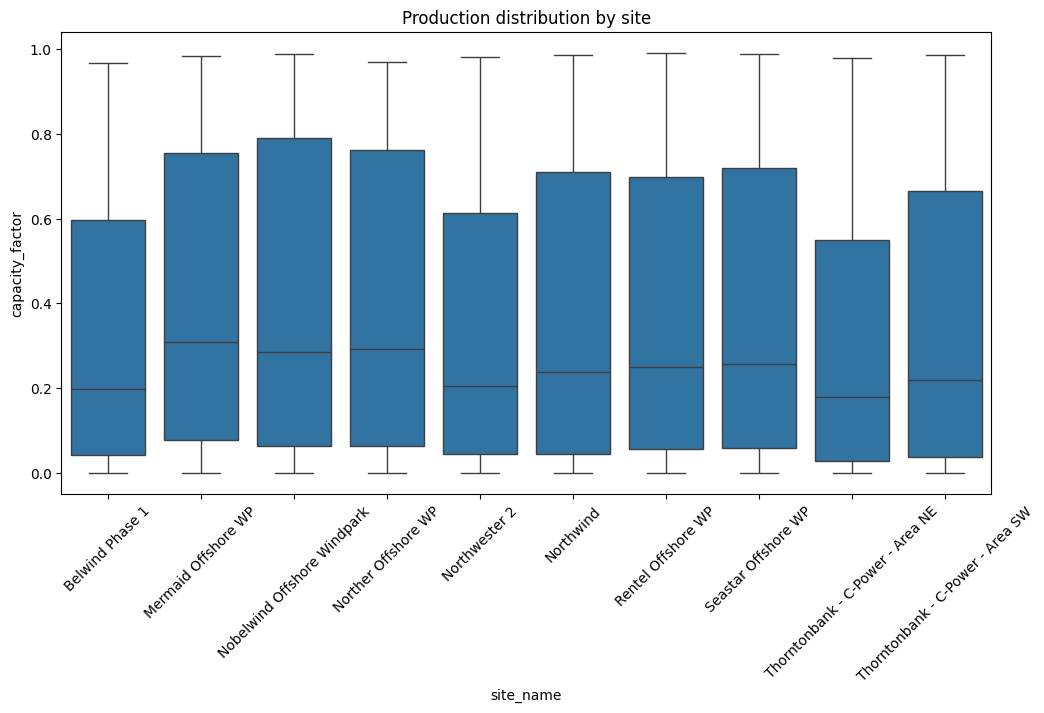

In [49]:
plt.figure(figsize=(12,6))

df['capacity_factor'] = df['production'] / df['installed_capacity']

sns.boxplot(
    data=df,
    x="site_name",
    y="capacity_factor"
)

plt.xticks(rotation=45)
plt.title("Production distribution by site")
plt.show()

Sites with low median → underperforming

Wide spread → unstable production

Many zeros → downtime or intermittency

Different shapes → different physics (wind regimes)

#### Relationships plots

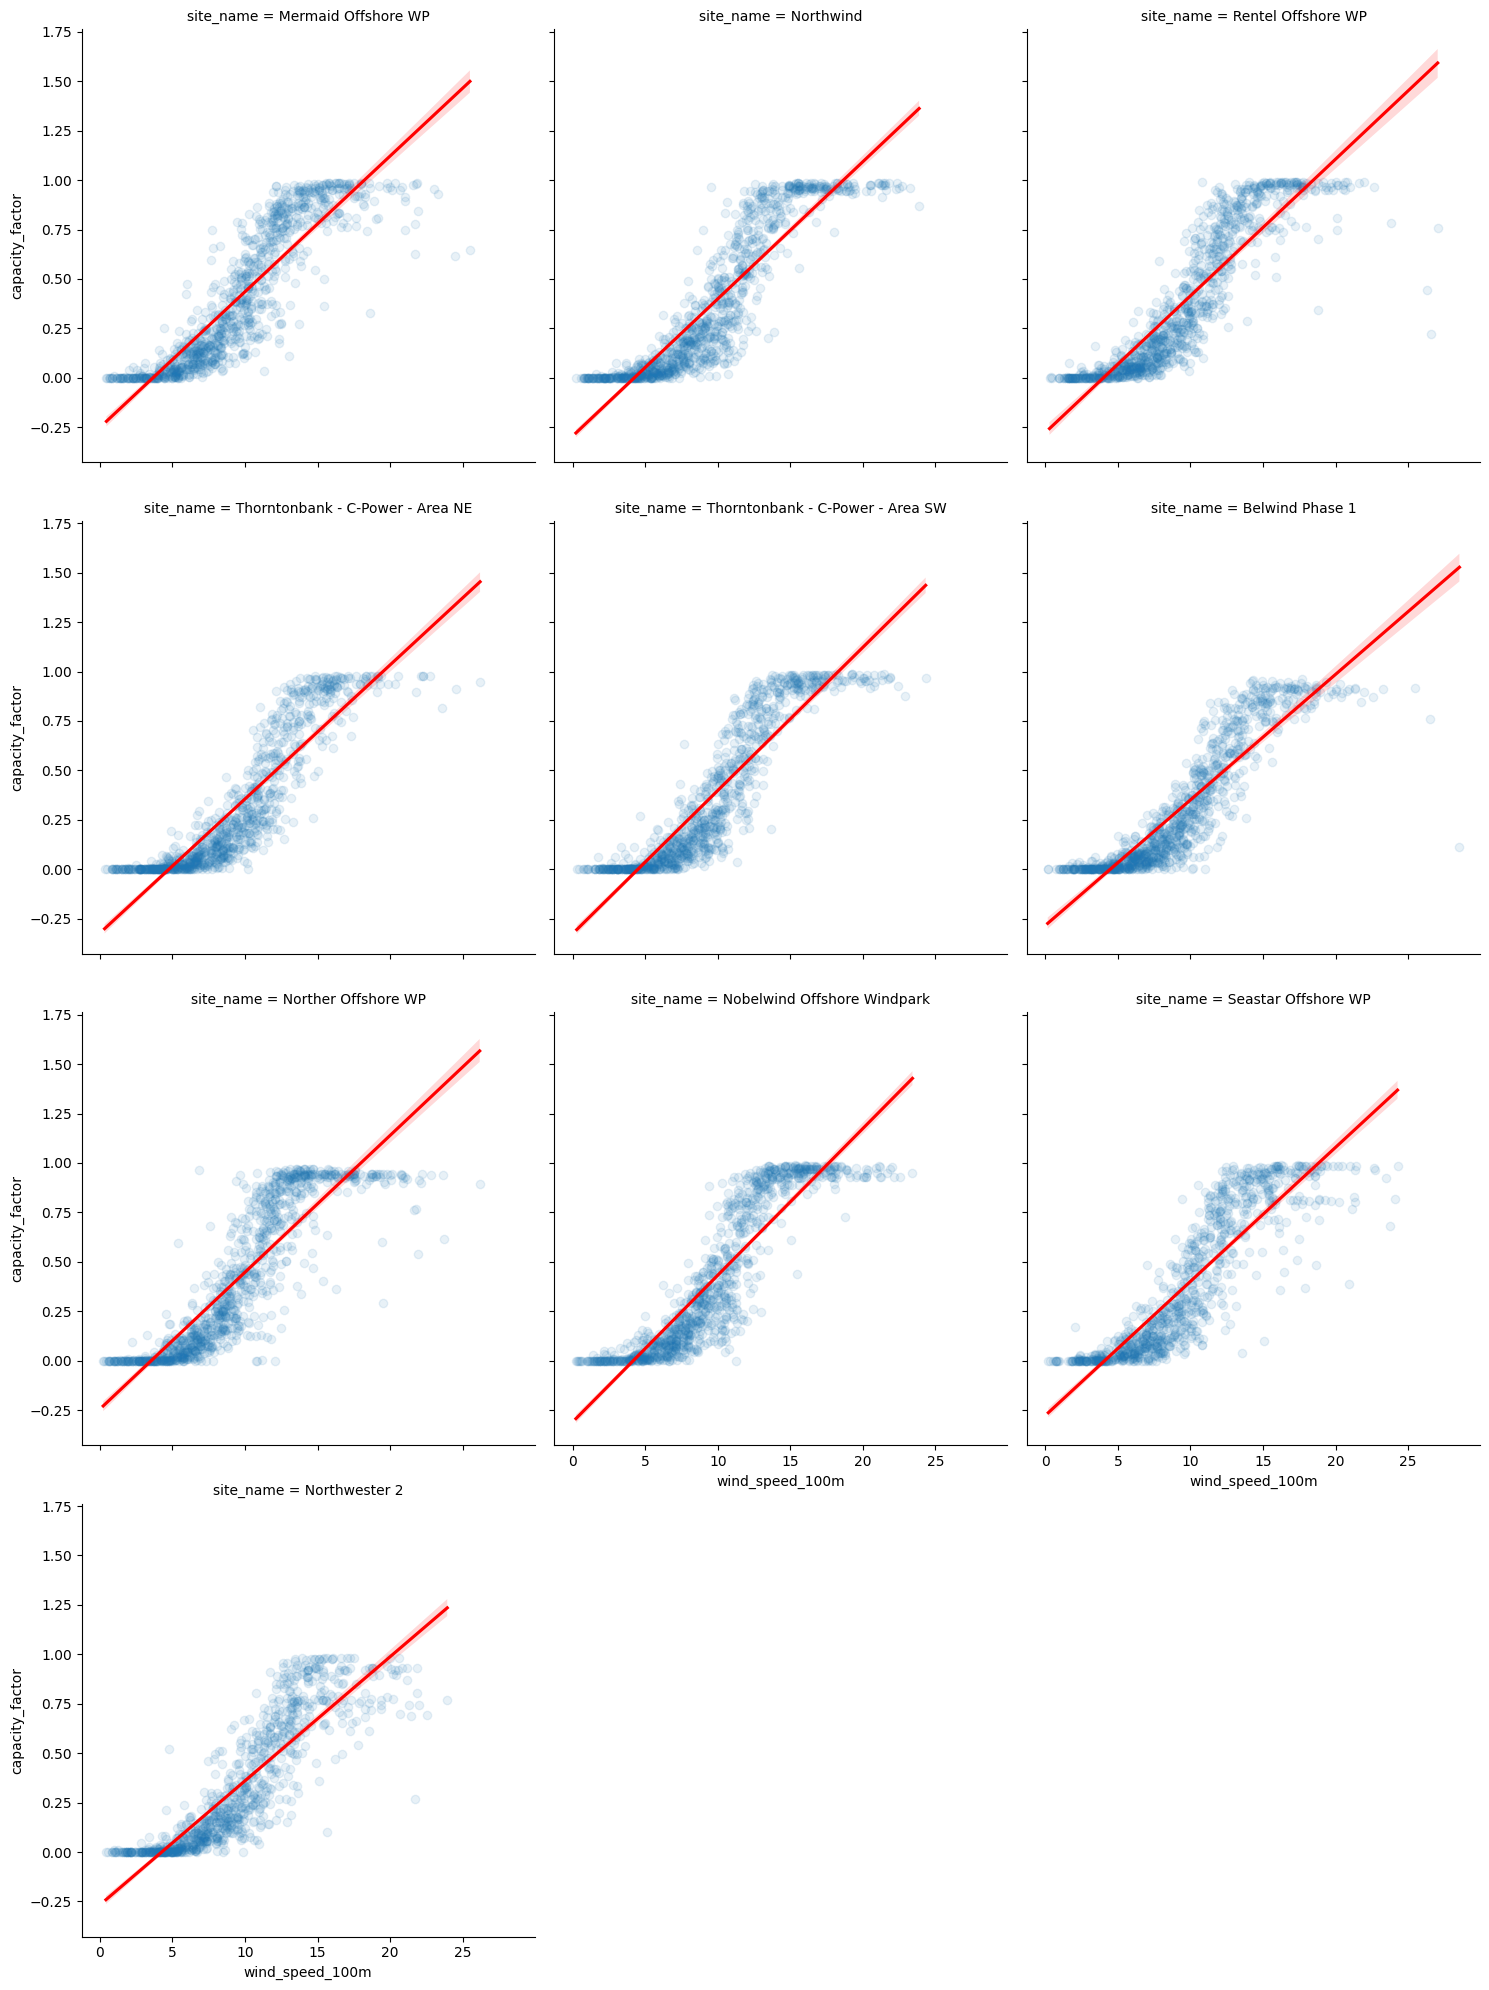

In [32]:
sns.lmplot(
    data=df.sample(10000),
    x="wind_speed_100m",
    y="capacity_factor",
    col="site_name",
    col_wrap=3,
    scatter_kws={'alpha':0.1},
    line_kws={'color': 'red'}
)
plt.show()

cut-in speed (no production below threshold)

ramp-up

saturation plateau
→ this is your physical power curve

#### Global feature importance

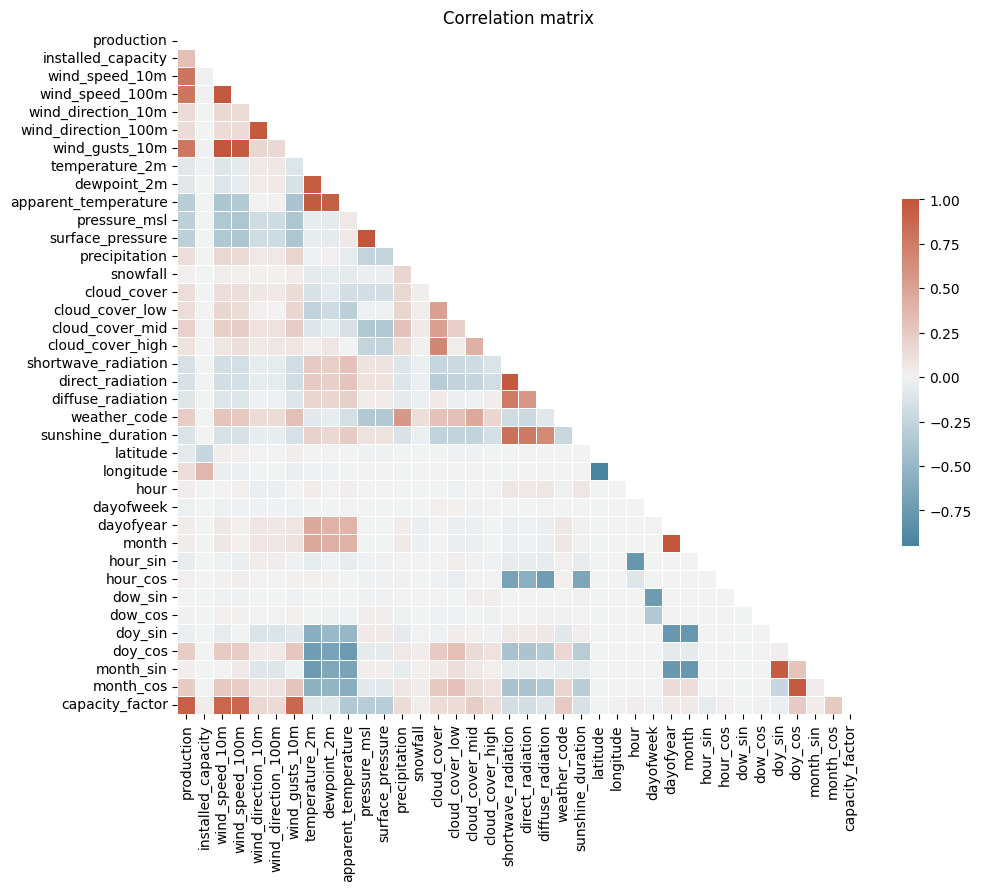

In [61]:
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(11, 9))
sns.heatmap(
    corr,
    mask=mask,
    cmap=sns.diverging_palette(230, 20, as_cmap=True),
    center=0,
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .5}
)

plt.title("Correlation matrix")
plt.show()

#### Seasonality analysis

**Hourly pattern**

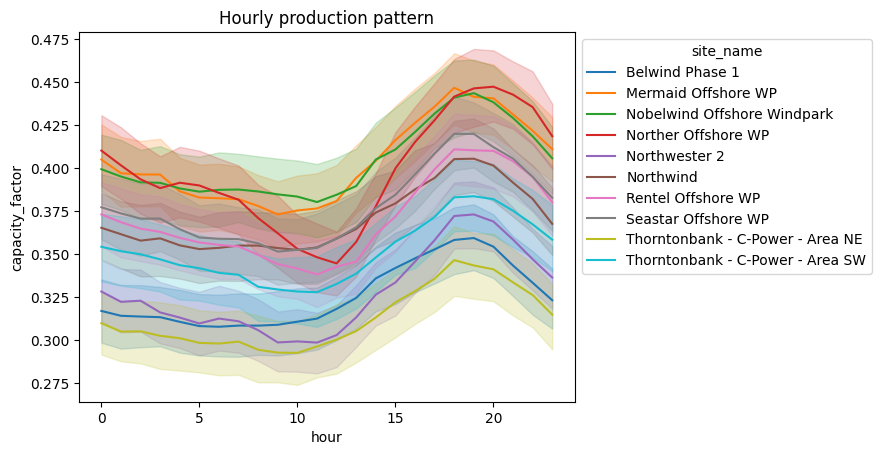

In [55]:
ax = sns.lineplot(
    data=df,
    x="hour",
    y="capacity_factor",
    hue="site_name"
)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.title("Hourly production pattern")
plt.show()

**Day of week pattern**

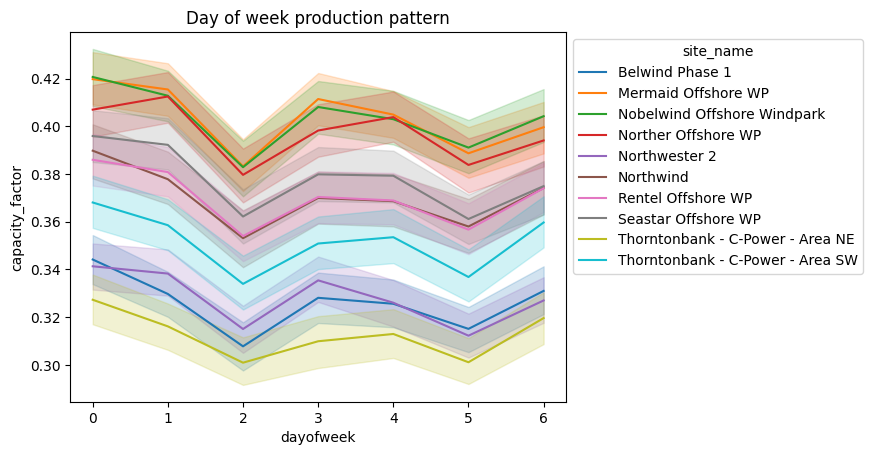

In [58]:
ax = sns.lineplot(
    data=df,
    x="dayofweek",
    y="capacity_factor",
    hue="site_name"
)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.title("Day of week production pattern")
plt.show()

**Day of year pattern**

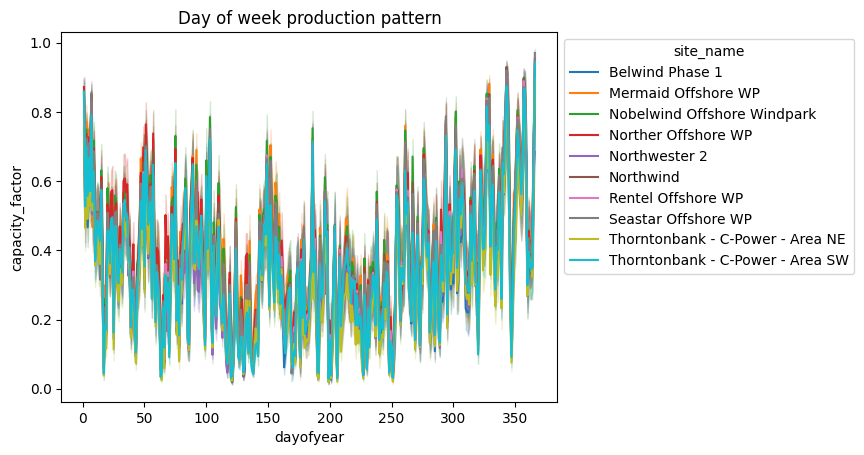

In [59]:
ax = sns.lineplot(
    data=df,
    x="dayofyear",
    y="capacity_factor",
    hue="site_name"
)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.title("Day of week production pattern")
plt.show()

**Monthly pattern**

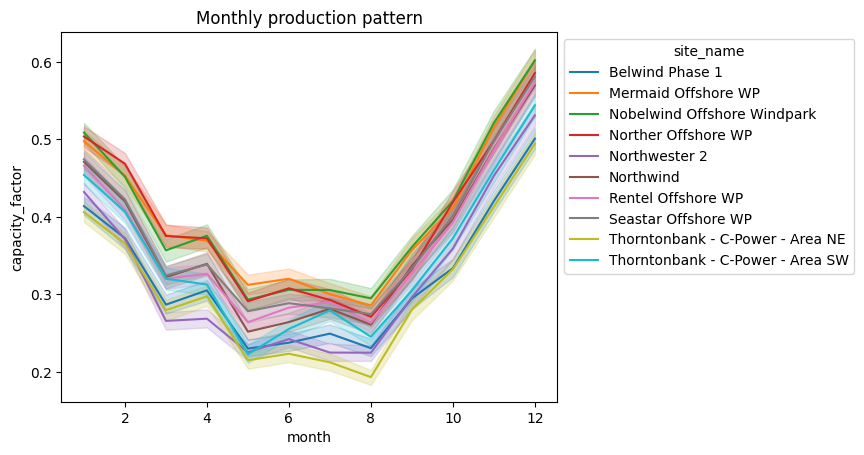

In [56]:
ax = sns.lineplot(
    data=df,
    x="month",
    y="capacity_factor",
    hue="site_name"
)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.title("Monthly production pattern")
plt.show()

**Yearly seasonality**

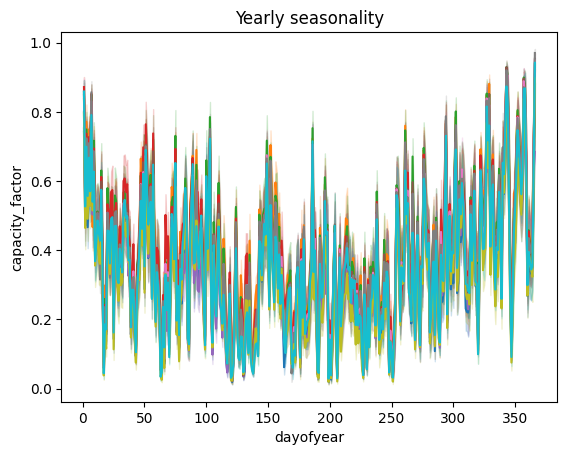

In [36]:
sns.lineplot(
    data=df,
    x="dayofyear",
    y="capacity_factor",
    hue="site_name",
    legend=False
)
plt.title("Yearly seasonality")
plt.show()

**Heatmap**

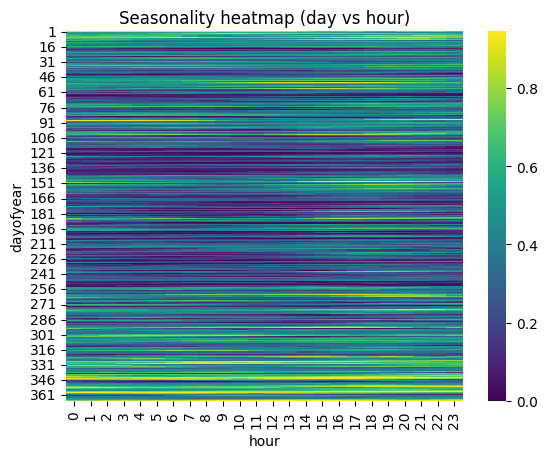

In [37]:
pivot = df.pivot_table(
    index="dayofyear",
    columns="hour",
    values="capacity_factor",
    aggfunc="mean"
)

sns.heatmap(pivot, cmap="viridis")
plt.title("Seasonality heatmap (day vs hour)")
plt.show()

**Per-site heatmap**

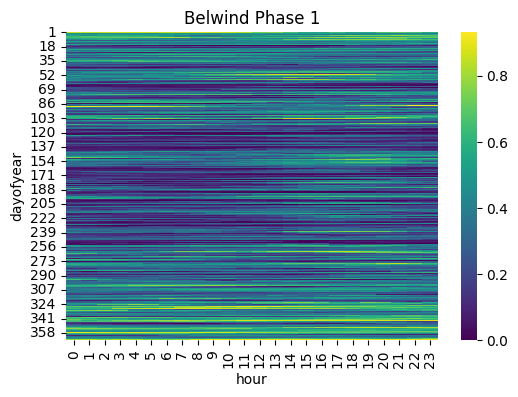

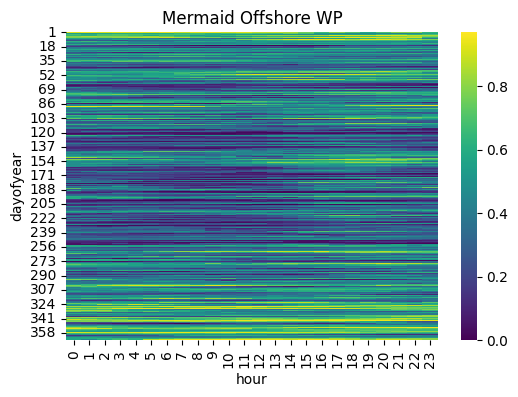

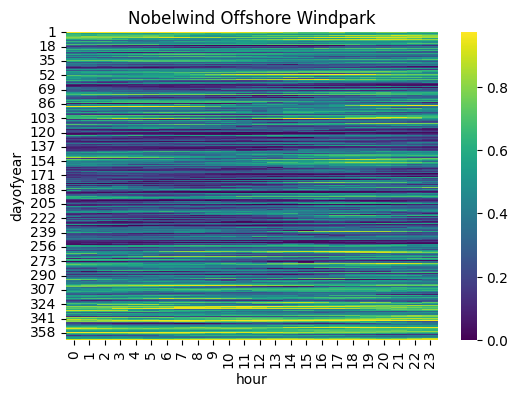

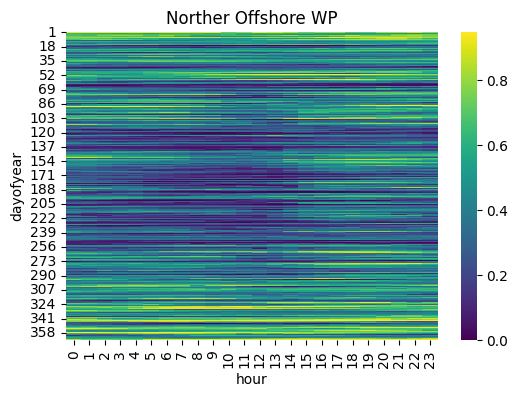

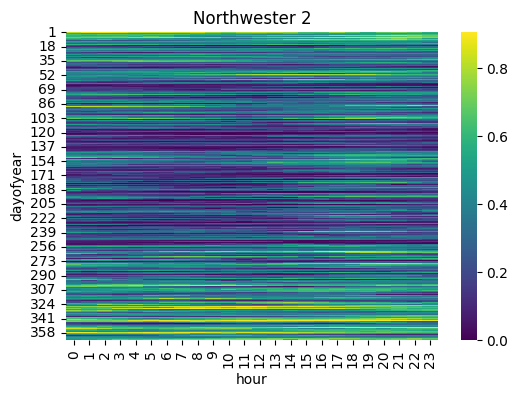

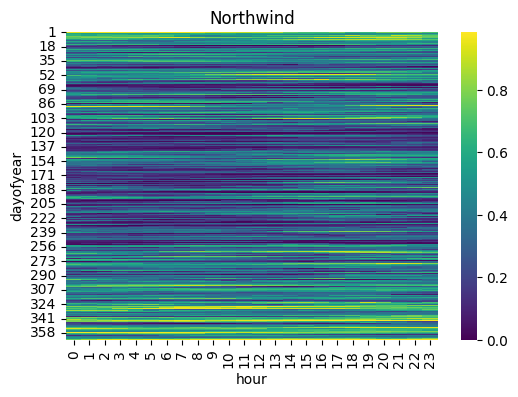

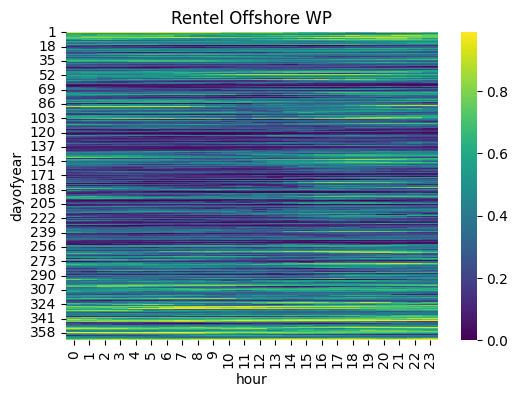

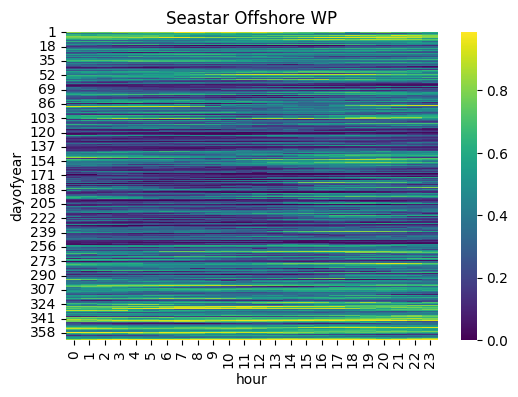

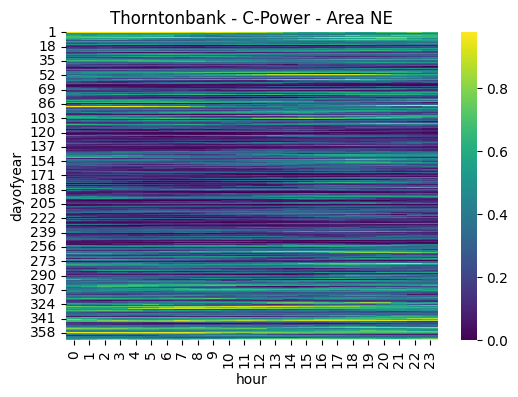

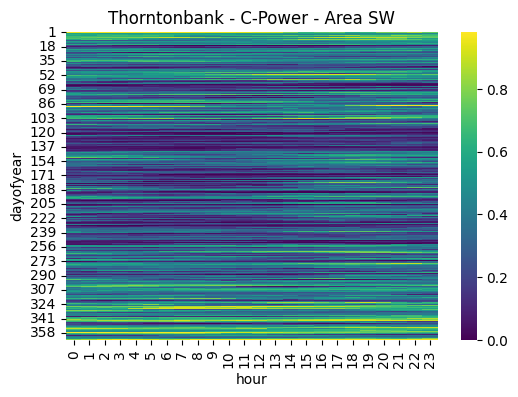

In [38]:
for site in df['site_name'].unique():
    pivot = df[df['site_name'] == site].pivot_table(
        index="dayofyear",
        columns="hour",
        values="capacity_factor",
        aggfunc="mean"
    )
    
    plt.figure(figsize=(6,4))
    sns.heatmap(pivot, cmap="viridis")
    plt.title(site)
    plt.show()